# Load dog data

In [14]:
import os
from PIL import Image
import numpy as np
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt
from torchvision import datasets, transforms

basedir = 'data/Dog_Images/'

In [15]:
images = []
images_resize = []
labels = []
transform_resize = transforms.Compose([transforms.Resize(128),
                                       transforms.CenterCrop(128)])
for x in os.listdir(basedir):
    if os.path.isdir(basedir+x+'/'):
        for y in os.listdir(basedir+x+'/'):
            imagedir = basedir + x + '/' + y
            annodir = 'data/Dog_Annotation/' + x + '/' + y.split('.')[0]
            with open(annodir, 'r', encoding='utf-8') as file:
                content = file.read()
            labels.append(content)
            img = Image.open(imagedir)
            images.append(img)
            images_resize.append(transform_resize(img))

In [16]:
class DogDataSet(Dataset):
    def __init__(self, imgs, labels):
        self.data = imgs
        self.label = labels
        self.transform = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5),
                                             transforms.RandomApply([transforms.RandomRotation(degrees=15)], p=0.3), 
                                             transforms.ToTensor(),
                                             transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.transform(self.data[index])
    

In [17]:
train_dataset = DogDataSet(images_resize, labels)
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=64,
                              shuffle=True,
                              num_workers=0)

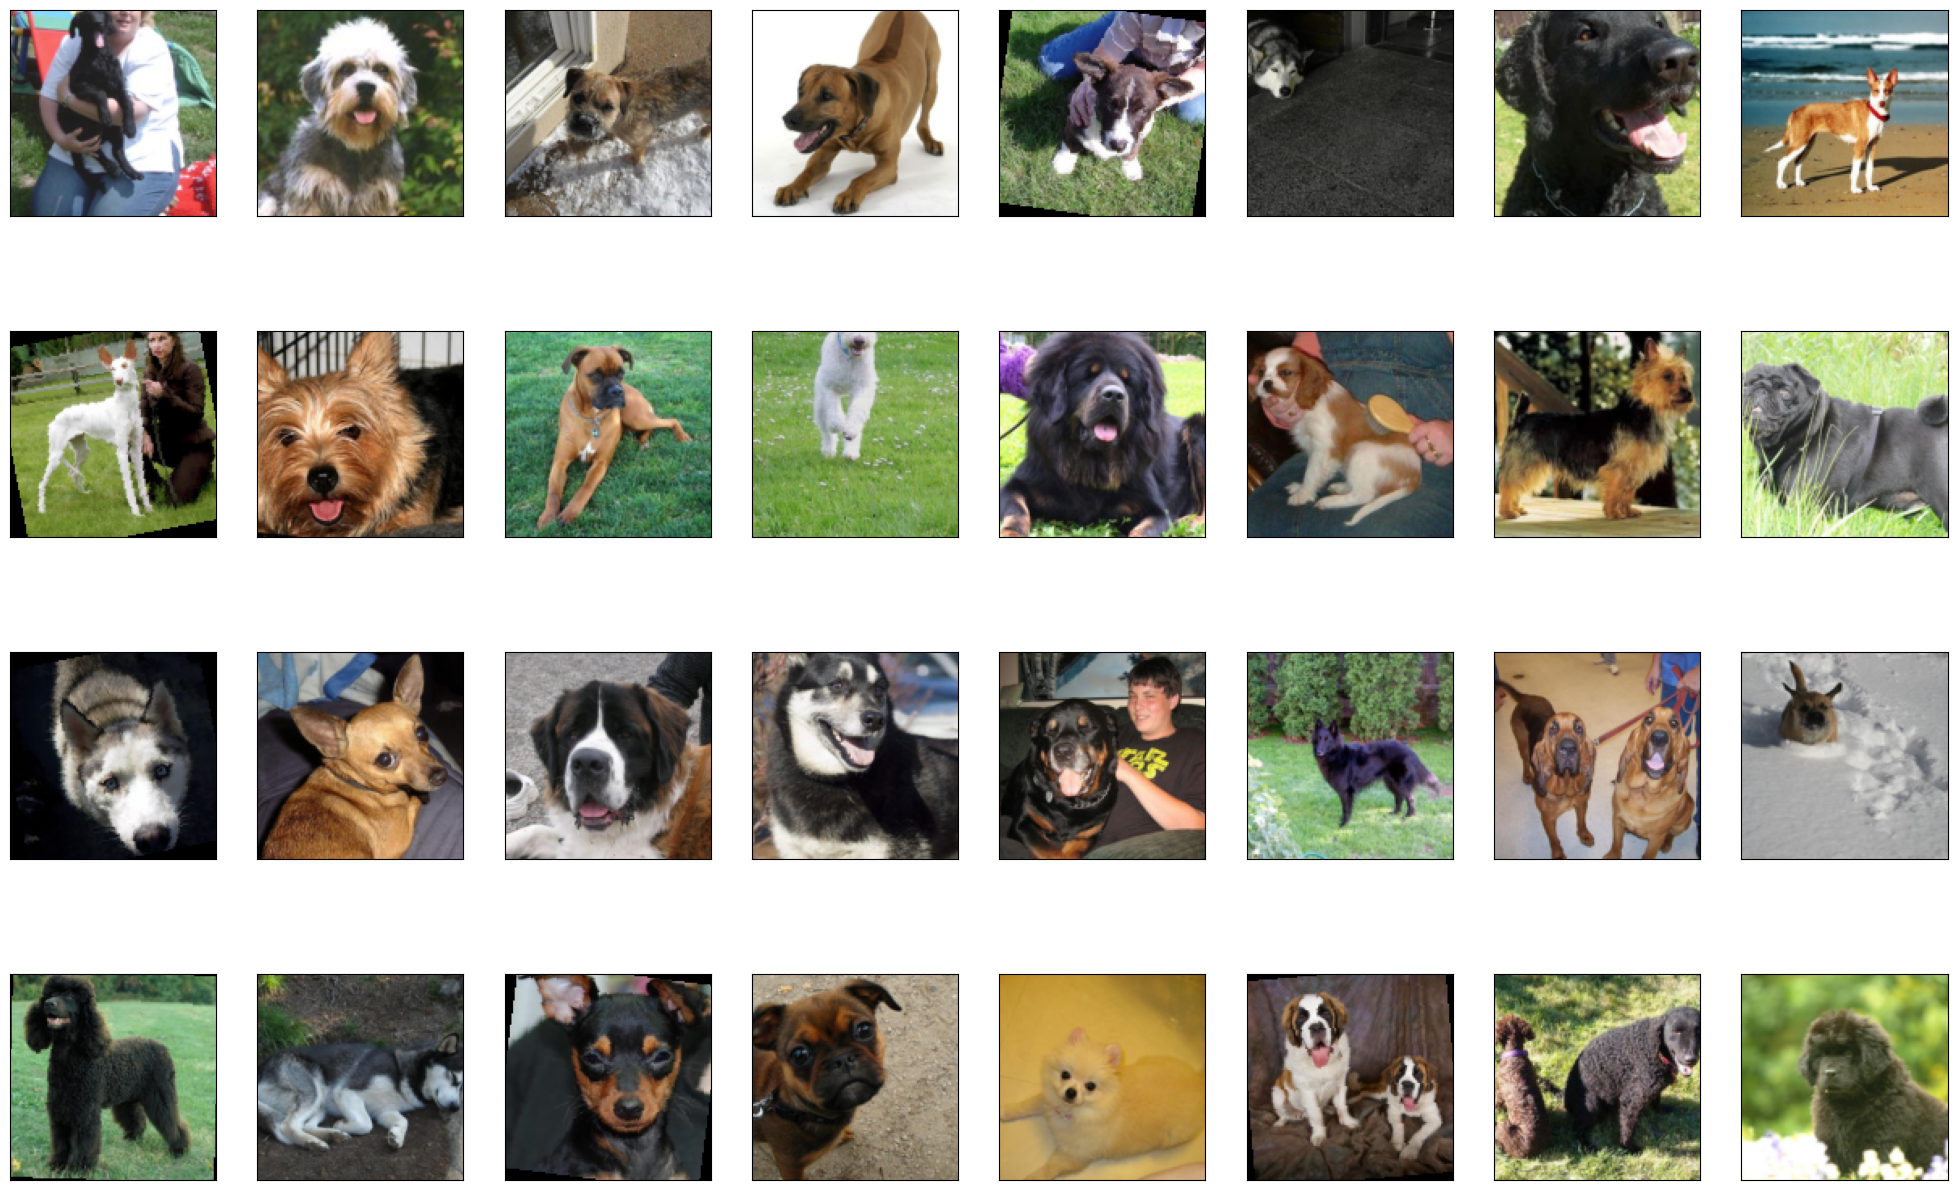

In [18]:
x = next(iter(train_dataloader))

fig = plt.figure(figsize=(25, 16))
for ii, img in enumerate(x):
    if ii < 32:
        ax = fig.add_subplot(4, 8, ii + 1, xticks=[], yticks=[])
        
        img = img.numpy().transpose(1, 2, 0)
        plt.imshow((img+1.)/2.)

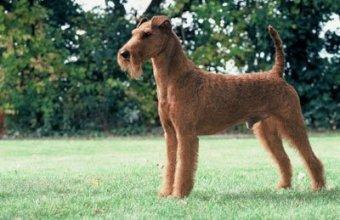

In [19]:
images[921]

In [20]:
train_dataset[0].shape

torch.Size([3, 128, 128])

In [57]:
l = nn.Conv2d(3, 96, kernel_size=11, stride=2, padding=5)

In [58]:
m = nn.MaxPool2d(kernel_size=2, stride=2)

In [65]:
(m(nn.ReLU()(l(train_dataset[0])))).shape

torch.Size([96, 32, 32])

In [70]:
l = nn.Sequential(#(3, 128, 128)
            nn.Conv2d(3, 96, kernel_size=11, stride=2, padding=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))

l2 = nn.Sequential(
            nn.Conv2d(96, 256, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))


In [71]:
l2(l(train_dataset[0])).shape

torch.Size([256, 8, 8])

In [149]:
from torch import nn
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(  #(3, 128, 128)
            nn.Conv2d(3, 96, kernel_size=11, stride=2, padding=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # (96, 32, 32)
            nn.Conv2d(96, 256, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # (256, 8, 8)
            nn.Conv2d(256, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (128, 2, 2)
            nn.Flatten(), # (512,)
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.Linear(512, 2048),
            nn.ReLU(inplace=True), 
            nn.Unflatten(1, (2, 32, 32)), # Unflattens dimension 1 into shape (2, 32, 32)
            nn.Conv2d(2, 8, kernel_size=3, stride=1, padding=1), # (8, 32, 32)
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), # (8, 64, 64)
            nn.Conv2d(8, 8, kernel_size=5, stride=1, padding=2), # (8, 64, 64)
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True), # (8, 128, 128)
            nn.Conv2d(8, 3, kernel_size=11, stride=1, padding=5), # (3, 128, 128)
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x_hidden = self.encoder(x)
        x_out = self.decoder(x_hidden)
        return x_hidden, x_out

In [150]:
model = AutoEncoder()

In [151]:
sum([p.numel() for p in model.encoder.parameters()])

1207296

In [152]:
sum([p.numel() for p in model.decoder.parameters()])

1055291

In [156]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [158]:
import numpy as np
n_epochs = 3
batch_size = 32
losses = []
for i in range(n_epochs):
    train_dataloader = DataLoader(dataset=train_dataset,
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=0)
    data_iterator = iter(train_dataloader)
    for batch_idx, x in enumerate(train_dataloader):
        opt.zero_grad()
        hidden, out = model(x)
        cur_loss = loss_fn(out, x)
        losses.append(cur_loss.item())
        cur_loss.backward()
        opt.step()
        if batch_idx % 10 == 0:
            print(f"batch_idx, Loss={np.array(losses).mean()}")

batch_idx, Loss=0.2702925503253937
batch_idx, Loss=0.28065142983740027
batch_idx, Loss=0.2863954738492057
batch_idx, Loss=0.2874573406673247
batch_idx, Loss=0.2861283854013536
batch_idx, Loss=0.28664088453732284
batch_idx, Loss=0.28624540274260474


KeyboardInterrupt: 

In [92]:
train_dataloader()

TypeError: 'DataLoader' object is not callable

In [85]:
model.encoder(train_dataset[0:4])

TypeError: pic should be PIL Image or ndarray. Got <class 'list'>